In [4]:
import re
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
df=pd.read_csv("emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [7]:
print(df.isna().sum())

,0
text,0
spam,0


In [8]:
df.duplicated().sum()

np.int64(33)

In [9]:
df.drop_duplicates(inplace=True)
df.reset_index(inplace=True,drop=True)

In [12]:
counts=df["spam"].value_counts()
print(counts)

spam
0    4327
1    1368
Name: count, dtype: int64


In [13]:
df['length']=df["text"].apply(len)

In [14]:
print(df.head())

                                                text  spam  length
0  Subject: naturally irresistible your corporate...     1    1484
1  Subject: the stock trading gunslinger  fanny i...     1     598
2  Subject: unbelievable new homes made easy  im ...     1     448
3  Subject: 4 color printing special  request add...     1     500
4  Subject: do not have money , get software cds ...     1     235


/tmp/ipython-input-474/2869882699.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


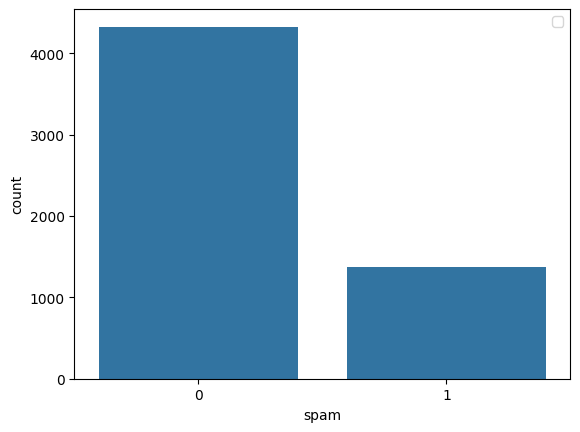

In [17]:
sns.countplot(x=df['spam'])
plt.legend()
plt.show()

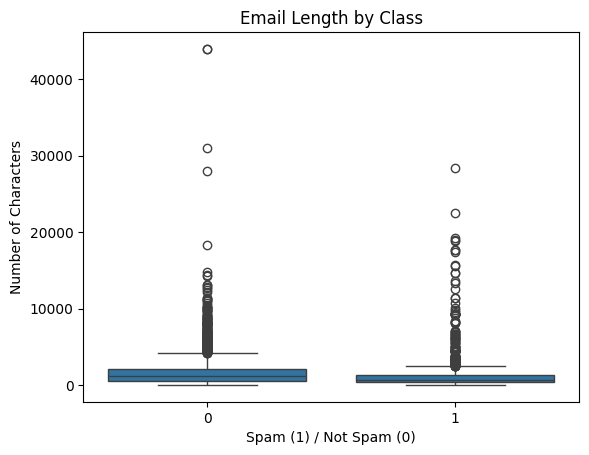

In [18]:
sns.boxplot(x='spam', y='length', data=df)
plt.title("Email Length by Class")
plt.xlabel("Spam (1) / Not Spam (0)")
plt.ylabel("Number of Characters")
plt.show()

In [21]:
df["spam"].nunique()

2

In [22]:
import plotly.express as px
fig=px.pie(df['spam'],values=df["spam"].values)
fig.show()

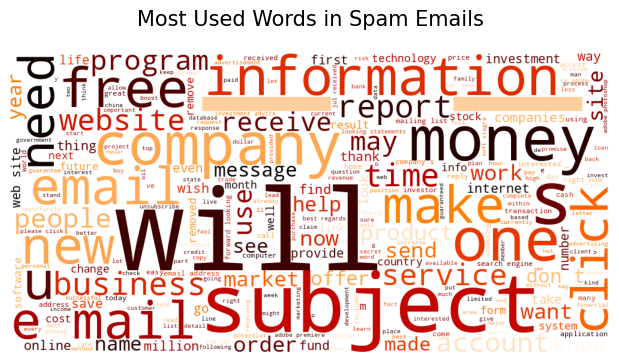

In [24]:
from wordcloud import WordCloud, STOPWORDS
df_spam = df[df['spam'] == 1].copy()

# Make a big string of all words in spam emails
comment_words = ''

# Words to ignore (like 'the', 'and', 'is')
stopwords = set(STOPWORDS)

# Go through each spam email
for val in df_spam['text']:
    val = str(val)  # make sure it is text
    tokens = val.split()  # split into separate words
    tokens = [word.lower() for word in tokens]  # make all words lowercase
    comment_words += " ".join(tokens) + " "  # add words to big string

# Make the word cloud picture
wordcloud = WordCloud(
    width=1000, height=500,
    background_color='white',
    stopwords=stopwords,  # ignore common words
    min_font_size=10,
    max_words=1000,
    colormap='gist_heat_r'
).generate(comment_words)

# Show the word cloud
plt.figure(figsize=(6,6))
plt.title('Most Used Words in Spam Emails', fontsize=15, pad=20)
plt.imshow(wordcloud)  # show image
plt.axis("off")         # hide axes
plt.tight_layout(pad=0)
plt.show()

In [25]:
df.head()

,text,spam,length
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [27]:
df.shape


(5695, 3)

In [28]:

from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=3000)
cv.fit(df["text"])

CountVectorizer(max_features=3000)

In [29]:
y=df["spam"]
y.head()

,spam
0,1
1,1
2,1
3,1
4,1


In [32]:
x=cv.transform(df["text"]).toarray()
z=df["length"]

temp_df = pd.concat([
    pd.DataFrame(x, index=df.index),
    pd.DataFrame(z, index=df.index)
], axis=1)
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,length
0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,7,0,0,0,0,0,1484
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,598
2,0,0,0,0,0,0,0,0,0,0,...,0,5,0,1,0,0,0,0,0,448
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,500
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,235


In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(temp_df,y,test_size=0.2,random_state=42)

In [40]:
x_test

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,length
1436,0,0,0,0,0,0,0,0,0,0,...,0,2,0,1,0,0,0,0,0,-0.524085
748,0,0,0,0,0,0,0,0,0,0,...,0,2,0,2,0,0,0,0,0,-0.318099
4112,0,0,0,0,0,0,0,0,0,0,...,0,4,0,0,0,0,0,0,0,0.183711
1448,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-0.639735
3891,0,0,0,0,0,1,1,4,0,0,...,0,7,0,4,0,0,0,0,0,0.922281
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2760,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,-0.242654
219,0,0,0,0,0,0,0,0,0,0,...,0,1,0,2,0,0,0,0,0,-0.695822
1831,0,0,0,0,0,0,1,0,1,1,...,0,0,0,1,0,0,0,0,0,-0.057019
1115,2,1,0,0,0,0,0,0,0,0,...,0,10,0,3,0,0,0,0,0,-0.198975


In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train["length"]=scaler.fit_transform(x_train[['length']])
x_test["length"]=scaler.transform(x_test[['length']])

In [37]:
x_train

,0,1,2,3,4,5,6,7,8,9,...,2991,2992,2993,2994,2995,2996,2997,2998,2999,length
2857,0,0,0,0,0,0,0,0,0,0,...,0,1,0,2,0,0,0,0,0,-0.672494
43,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-0.638742
1891,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,-0.619881
3194,0,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,-0.310654
3441,0,0,0,0,0,0,0,0,0,0,...,0,8,0,15,0,0,0,0,0,0.746077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0,0,0,0,0,0,0,0,0,0,...,0,4,0,1,0,0,0,0,0,-0.272932
5191,0,0,0,0,0,0,1,0,2,0,...,0,5,0,1,0,0,0,0,0,-0.184085
5226,0,0,0,0,0,0,1,4,0,0,...,0,8,0,4,0,0,0,9,0,1.083099
5390,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,2,0,-0.480903


In [41]:
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)

In [42]:
from sklearn.linear_model import LogisticRegression
lo=LogisticRegression(random_state=42)
lo.fit(x_train,y_train)

LogisticRegression(random_state=42)

In [43]:
y_pred=lo.predict(x_test)

In [50]:
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score, recall_score, f1_score

print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_pred,y_test))
cm = confusion_matrix(y_test, y_pred)
print(cm)

0.9885864793678666
0.9796610169491525
0.9796610169491525
[[837   6]
 [  7 289]]


In [52]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('bow', CountVectorizer(max_features=3000), 'text'),
        ('length_scaler', StandardScaler(), ['length'])
    ]
)

In [55]:
from sklearn.pipeline import Pipeline
pipeline=Pipeline([
    ('preprcosseing',preprocessor),
    ('model',lo)
])

In [56]:
X = df[['text', 'length']]
y = df['spam']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score,confusion_matrix, precision_score, recall_score, f1_score

print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_pred,y_test))
cm = confusion_matrix(y_test, y_pred)
print(cm)

0.9868305531167691
0.976271186440678
0.976271186440678
[[836   7]
 [  8 288]]


In [64]:
new_email = pd.DataFrame({
    "text": ["You won a free iPhone!"],
    "length": [len("You won a free iPhone!")]
})

prediction = pipeline.predict(new_email)
print(prediction)

[1]
